In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("notebook-test").getOrCreate()
spark.range(5).show()
spark.stop()


+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [3]:
print(spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))
print(spark.sparkContext._jvm.java.lang.System.getProperty("java.vendor"))

17.0.17
Eclipse Adoptium


In [4]:
# Create SparkSession (entry point for Spark)
spark = (
    SparkSession.builder
    .master("local[*]")              # Use all available CPU cores
    .appName("KMeans_Performance_mini-project")  # Name of the Spark application
    .config("spark.driver.memory", "4g")  # Allocate memory for Spark driver
    .getOrCreate()                   # Create or reuse SparkSession
)

In [5]:
from pathlib import Path
import pandas as pd

def find_repo_root(start: Path | None = None) -> Path:
    """
    Repo root is defined as the directory that contains `data/dataset.txt`
    """
    start = (start or Path.cwd()).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "dataset.txt").exists():
            return p

    raise FileNotFoundError(
        "Cannot find repo root. Expected `data/dataset.txt` in a parent directory.\n"
        "Have you run the data preparation script?"
    )

# 1) find repo root robustly
repo_root = find_repo_root()

# 2) read dataset pointer
pointer_file = repo_root / "data" / "dataset.txt"
dataset_dir = Path(pointer_file.read_text(encoding="utf-8").strip())


In [6]:
# 3) load data
csv_path = str(next(dataset_dir.glob("*.csv")))   # Spark ต้องการ string path

sdf = (spark.read
       .option("header", True)
       .option("inferSchema", True)
       .csv(csv_path))

sdf.show(5, truncate=False)
sdf.printSchema()

+---+-------+--------+-------------------+-------------------+-----------------+------------------+-------+-------+------------+-------------------------------------------------------------------------------------+-------------------------+------------+----------+-----+----------+-------+----------+------------+-------------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
|ID |Source |Severity|Start_Time         |End_Time           |Start_Lat        |Start_Lng         |End_Lat|End_Lng|Distance(mi)|Description                                                                          |Street                   |City        |County    |State|Zipcode   |Country|Timezone  |Airport_Code|Weather_Timestamp  |T

In [8]:
sdf.head(), sdf.dtypes

(Row(ID='A-1', Source='Source2', Severity=3, Start_Time=datetime.datetime(2016, 2, 8, 5, 46), End_Time=datetime.datetime(2016, 2, 8, 11, 0), Start_Lat=39.865147, Start_Lng=-84.058723, End_Lat=None, End_Lng=None, Distance(mi)=0.01, Description='Right lane blocked due to accident on I-70 Eastbound at Exit 41 OH-235 State Route 4.', Street='I-70 E', City='Dayton', County='Montgomery', State='OH', Zipcode='45424', Country='US', Timezone='US/Eastern', Airport_Code='KFFO', Weather_Timestamp=datetime.datetime(2016, 2, 8, 5, 58), Temperature(F)=36.9, Wind_Chill(F)=None, Humidity(%)=91.0, Pressure(in)=29.68, Visibility(mi)=10.0, Wind_Direction='Calm', Wind_Speed(mph)=None, Precipitation(in)=0.02, Weather_Condition='Light Rain', Amenity=False, Bump=False, Crossing=False, Give_Way=False, Junction=False, No_Exit=False, Railway=False, Roundabout=False, Station=False, Stop=False, Traffic_Calming=False, Traffic_Signal=False, Turning_Loop=False, Sunrise_Sunset='Night', Civil_Twilight='Night', Nautical

In [9]:
print(sdf.shape)

PySparkAttributeError: [ATTRIBUTE_NOT_SUPPORTED] Attribute `shape` is not supported.

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


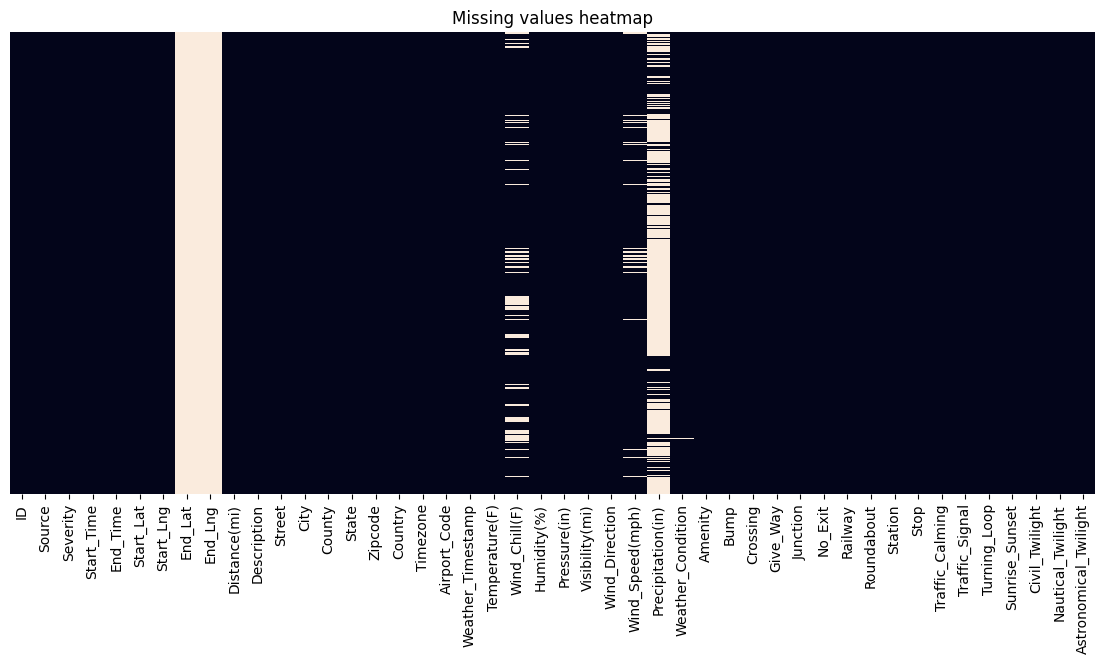

In [5]:
import seaborn as sns

# Missing value summary
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.concat([missing_counts, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
missing_summary

# Show a sample of rows that contain any missing values
if not missing_summary.empty:
    display(df[df.isnull().any(axis=1)].head())
else:
    print("No missing values found.")

# Quick visual overview
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing values heatmap")
plt.show()